In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import setup_plotting, switch_cwd_to_root

switch_cwd_to_root()

figure_dir = "figures/revision/supplement"
setup_plotting(figure_dir, display_dpi=300, save_dpi=300)

import colorsys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import squarify
from matplotlib.lines import Line2D

Changing working directory to /bonn-epyc/projects/dschaub/analysis-projects/xenium-tcr
Arial font found!


In [ ]:
data_dir = "data/xenium/processed"
path = f"{data_dir}/06.2-kidney_tcr_filtered.h5ad"
adata = sc.read_h5ad(path)
adata.obs["condition"].value_counts()

condition
ANCA       389390
Control    120749
Name: count, dtype: int64

In [5]:
tmp = adata.copy()

In [6]:
cond_dic = {
    "Control": [
        "XETG00088__0029040__Region_2__20240719__095641",
        "XETG00088__0029040__Region_3__20240719__095641",
        "XETG00088__0029041__Region_1__20240719__095642",
    ],
    "ANCA": [
        "XETG00088__0029040__Region_4__20240719__095642",
        "XETG00088__0029040__Region_5__20240719__095642",
        "XETG00088__0029040__Region_6__20240719__095642",
        "XETG00088__0029040__Region_7__20240719__095642",
        "XETG00088__0029041__Region_3__20240719__095642",
        "XETG00088__0029041__Region_4__20240719__095642",
        "XETG00088__0029041__Region_5__20240719__095642",
        "XETG00088__0029041__Region_6__20240719__095642",
        "XETG00088__0029041__Region_7__20240719__095642",
        "XETG00088__0029041__Region_8__20240719__095642",
    ],
    "BK-Virus": ["XETG00088__0029041__Region_2__20240719__095642"],
}
inverted_dict = {
    sample_id: condition
    for condition, sample_ids in cond_dic.items()
    for sample_id in sample_ids
}

# Assuming tmp.obs["sample"] contains the sample IDs
tmp.obs["condition"] = tmp.obs["sample"].replace(inverted_dict)

/tmp/ipykernel_1292747/1244299683.py:28: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  tmp.obs["condition"] = tmp.obs["sample"].replace(inverted_dict)


In [7]:
realt = ["CD4+", "CD8+", "MAIT", "NK/NKT", "TFH", "Tregs", "gdT"]
tmp = tmp[tmp.obs.tcell_subtype.isin(realt)]

In [8]:
# only concentrate on the vgenes
av = [x for x in tmp.var_names if x.startswith("TRAV")]
bv = [x for x in tmp.var_names if x.startswith("TRBV")]
gv = [x for x in tmp.var_names if x.startswith("TRGV")]
dv = [x for x in tmp.var_names if x.startswith("TRDV")]

In [ ]:
def get_dominant_v(tmp, vgenes):
    array = tmp[:, vgenes].X.toarray()
    max_indices = np.argmax(array, axis=1)
    _max_values = array[np.arange(array.shape[0]), max_indices]
    # pdb.set_trace()
    sorted_rows = np.sort(array, axis=1)[:, -2:]
    ties = sorted_rows[:, 0] == sorted_rows[:, 1]
    result = np.where(ties, -1, max_indices)
    # pdb.set_trace()
    return [vgenes[i] if i != -1 else "None" for i in result]

In [10]:
tmp.obs["AV"] = get_dominant_v(tmp, av)
tmp.obs["BV"] = get_dominant_v(tmp, bv)

/tmp/ipykernel_1292747/3013579335.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  tmp.obs["AV"] = get_dominant_v(tmp, av)


In [11]:
for sample in tmp.obs["sample"].unique():
    # print(sample)
    smp = tmp[tmp.obs["sample"] == sample].copy()
    print(sample, (smp.obs[["AV", "BV"]] != "None").all(1).sum())

XETG00088__0029040__Region_2__20240719__095641 11
XETG00088__0029040__Region_4__20240719__095642 222
XETG00088__0029041__Region_3__20240719__095642 424
XETG00088__0029041__Region_5__20240719__095642 324
XETG00088__0029040__Region_7__20240719__095642 291
XETG00088__0029040__Region_6__20240719__095642 401
XETG00088__0029041__Region_4__20240719__095642 342
XETG00088__0029040__Region_3__20240719__095641 1
XETG00088__0029041__Region_8__20240719__095642 518
XETG00088__0029041__Region_7__20240719__095642 212
XETG00088__0029041__Region_6__20240719__095642 14
XETG00088__0029041__Region_1__20240719__095642 5
XETG00088__0029040__Region_5__20240719__095642 162


In [12]:
control_bar = []
for sample in cond_dic["Control"]:
    smp = tmp[tmp.obs["sample"] == sample]
    x = (smp.obs[["AV", "BV"]] != "None").all(1).sum()
    control_bar.append(x)
anca_bar = []
for sample in cond_dic["ANCA"]:
    smp = tmp[tmp.obs["sample"] == sample]
    x = (smp.obs[["AV", "BV"]] != "None").all(1).sum()
    anca_bar.append(x)

In [13]:
tmp.obs["sample"].unique()

['XETG00088__0029040__Region_2__20240719__095641', 'XETG00088__0029040__Region_4__20240719__095642', 'XETG00088__0029041__Region_3__20240719__095642', 'XETG00088__0029041__Region_5__20240719__095642', 'XETG00088__0029040__Region_7__20240719__095642', ..., 'XETG00088__0029041__Region_8__20240719__095642', 'XETG00088__0029041__Region_7__20240719__095642', 'XETG00088__0029041__Region_6__20240719__095642', 'XETG00088__0029041__Region_1__20240719__095642', 'XETG00088__0029040__Region_5__20240719__095642']
Length: 13
Categories (13, object): ['XETG00088__0029040__Region_2__20240719__095641', 'XETG00088__0029040__Region_3__20240719__095641', 'XETG00088__0029040__Region_4__20240719__095642', 'XETG00088__0029040__Region_5__20240719__095642', ..., 'XETG00088__0029041__Region_5__20240719__095642', 'XETG00088__0029041__Region_6__20240719__095642', 'XETG00088__0029041__Region_7__20240719__095642', 'XETG00088__0029041__Region_8__20240719__095642']

In [14]:
samples = cond_dic["ANCA"]

In [15]:
[samples[x] for x in [2, 4, -1]]

['XETG00088__0029040__Region_6__20240719__095642',
 'XETG00088__0029041__Region_3__20240719__095642',
 'XETG00088__0029041__Region_8__20240719__095642']

In [16]:
most_cd4 = {}
most_cd8 = {}
for k in range(len(samples)):  # [2,4,-1]
    sample_name = samples[k]
    smp = tmp[tmp.obs["sample"] == sample_name]
    mapbol = (smp.obs[["AV", "BV"]] != "None").all(1)
    smp = smp[mapbol]
    cd4 = smp[smp.obs["tcell_subtype"] == "CD4+"]
    cd8 = smp[smp.obs["tcell_subtype"] == "CD8+"]
    most_cd4[sample_name] = cd4.obs[["AV", "BV"]].value_counts().to_dict()
    most_cd8[sample_name] = cd8.obs[["AV", "BV"]].value_counts().to_dict()
    # break
    # x = smp[mapbol].obs[["AV","BV"]].value_counts().head(10)
    # result = x.to_dict()
    # most_clone_dic[sample_name] = result

In [17]:
def aggregate_singles(dir_most):
    cd_rep = {}
    for pair, srs in dir_most.items():
        srs = pd.Series(srs)
        others = (srs == 1).sum()
        srs = srs[srs != 1]
        srs.loc["other"] = others
        cd_rep[pair] = srs
    return cd_rep


cd4_rep = aggregate_singles(most_cd4)
cd8_rep = aggregate_singles(most_cd8)

In [18]:
setpair = ()
for key, val in cd4_rep.items():
    setpair = set(setpair).union(set(val.keys()))
for key, val in cd8_rep.items():
    setpair = set(setpair).union(set(val.keys()))

In [19]:
len(setpair)

159

In [20]:
def generate_distinct_colors(n=200):
    colors = []
    for i in range(n):
        hue = i / n
        sat = 0.65 + 0.35 * ((i % 4) / 3)
        val = 0.75 + 0.25 * ((i // 4) % 2)
        rgb = colorsys.hsv_to_rgb(hue, sat, val)
        colors.append(rgb)
    return colors


# Get your unique pairs
n_colors = len(setpair)
palette = generate_distinct_colors(n_colors)

# Create the color dictionary
colordic = {pair: palette[k] for k, pair in enumerate(setpair)}
colordic[("other", "")] = (0.5, 0.5, 0.5)

# Plot REpertoireMAp

In [25]:
def plot_squares_repertoire(data, sample):
    # Separate out 'other'
    data_sorted = data.sort_values(ascending=False)
    other_value = data_sorted[("other", "")]
    rest = data_sorted.drop(("other", ""))

    # Calculate value proportions
    total_value = data_sorted.sum()
    other_frac = other_value / total_value
    main_frac = 1 - other_frac

    # Define dimensions
    fig_width = 1
    fig_height = 1
    main_width = fig_width * main_frac
    other_width = fig_width * other_frac

    # Normalize rest values
    normed_vals = squarify.normalize_sizes(rest.values, main_width, fig_height)
    rest_rects = squarify.squarify(normed_vals, x=0, y=0, dx=main_width, dy=fig_height)

    # Labels and colors
    rest_labels = [f"{k[0]} / {k[1]}" for k in rest.index]
    rest_colors = [colordic[k] for k in rest.index]

    # factor
    # factor = np.sqrt(total_value/100)
    # Plot
    # fig, ax = plt.subplots(figsize=(3*factor, 3*factor))
    fig, ax = plt.subplots(figsize=(5, 5))

    # Draw rest of the treemap
    for rect, label, color, val in zip(
        rest_rects, rest_labels, rest_colors, rest.values
    ):
        ax.add_patch(
            plt.Rectangle(
                (rect["x"], rect["y"]),
                rect["dx"],
                rect["dy"],
                facecolor=color,
                edgecolor="white",
                linewidth=1,
            )
        )

    # Draw the 'other' rectangle
    ax.add_patch(
        plt.Rectangle(
            (main_width, 0),
            other_width,
            fig_height,
            facecolor="gray",
            edgecolor="white",
            linewidth=1,
        )
    )
    # ax.text(main_width + other_width / 2, fig_height / 2,
    #         f"Single clone", ha='center', va='center', fontsize=10, color='white')

    # Plot settings
    # ax.set_xlim(0, fig_width)
    # ax.set_ylim(0, fig_height)
    # ax.set_aspect('equal')
    ax.axis("off")
    # plt.title(f"Repertoire {sample.split('__')[2]} {sample[-4:-1]}", fontsize=14)
    plt.tight_layout()
    # plt.show()
    # plt.savefig(f"Images/squarify_{sample}.pdf",dpi=300)

In [28]:
for sample, df in cd8_rep.items():
    print(sample, df.sum())

XETG00088__0029040__Region_4__20240719__095642 71
XETG00088__0029040__Region_5__20240719__095642 61
XETG00088__0029040__Region_6__20240719__095642 217
XETG00088__0029040__Region_7__20240719__095642 87
XETG00088__0029041__Region_3__20240719__095642 140
XETG00088__0029041__Region_4__20240719__095642 103
XETG00088__0029041__Region_5__20240719__095642 129
XETG00088__0029041__Region_6__20240719__095642 8
XETG00088__0029041__Region_7__20240719__095642 52
XETG00088__0029041__Region_8__20240719__095642 180


In [29]:
for sample, df in cd4_rep.items():
    print(sample, df.sum())

XETG00088__0029040__Region_4__20240719__095642 113
XETG00088__0029040__Region_5__20240719__095642 60
XETG00088__0029040__Region_6__20240719__095642 118
XETG00088__0029040__Region_7__20240719__095642 157
XETG00088__0029041__Region_3__20240719__095642 193
XETG00088__0029041__Region_4__20240719__095642 194
XETG00088__0029041__Region_5__20240719__095642 126
XETG00088__0029041__Region_6__20240719__095642 3
XETG00088__0029041__Region_7__20240719__095642 100
XETG00088__0029041__Region_8__20240719__095642 196


# BubblePlot

In [30]:
most_clones = {}
for k in range(len(samples)):  # [2,4,-1]
    sample_name = samples[k]
    smp = tmp[tmp.obs["sample"] == sample_name]
    mapbol = (smp.obs[["AV", "BV"]] != "None").all(1)
    smp = smp[mapbol]
    most_clones[sample_name] = smp.obs[["AV", "BV"]].value_counts().to_dict()

In [31]:
df = pd.DataFrame(most_clones).fillna(0).astype(int)

In [32]:
nonzero_counts = (df > 0).sum(axis=1)

# Filter rows with only 1 or 2 non-zero entries
rare_combinations = df[nonzero_counts <= 3]

In [33]:
rc = rare_combinations[rare_combinations.sum(1) > 5]

In [34]:
# Reset index and name the index columns
df_long = rc.reset_index()
df_long.columns.values[:2] = ["AV", "BV"]  # Rename index columns

# Melt to long format
df_long = df_long.melt(id_vars=["AV", "BV"], var_name="Sample", value_name="CloneSize")

# Filter non-zero clone sizes
df_long = df_long[df_long["CloneSize"] > 0]

# Create a column for AV/BV combo string (optional: cleaner y-axis labels)
df_long["AVBV"] = df_long["AV"] + " / " + df_long["BV"]
# Cap the CloneSize at 10
df_long["CloneSizeCapped"] = df_long["CloneSize"].clip(upper=5)
# Step 1: Make sure the (AV, BV) pair is accessible
df_long["pair"] = list(zip(df_long["AV"], df_long["BV"]))

# Step 2: Map the color from your dictionary
df_long["color"] = df_long["pair"].map(colordic)
df_long["AVBV"] = df_long["AVBV"].str.replace("*", "")
df_long["Sample"] = pd.Categorical(df_long["Sample"], categories=samples, ordered=True)
sample_name_map = {sn: f"ANCA {idx}" for idx, sn in enumerate(samples)}
df_long["Sample_Display"] = df_long["Sample"].map(sample_name_map)

In [149]:
sample_name_map

{'XETG00088__0029040__Region_4__20240719__095642': 'ANCA 0',
 'XETG00088__0029040__Region_5__20240719__095642': 'ANCA 1',
 'XETG00088__0029040__Region_6__20240719__095642': 'ANCA 2',
 'XETG00088__0029040__Region_7__20240719__095642': 'ANCA 3',
 'XETG00088__0029041__Region_3__20240719__095642': 'ANCA 4',
 'XETG00088__0029041__Region_4__20240719__095642': 'ANCA 5',
 'XETG00088__0029041__Region_5__20240719__095642': 'ANCA 6',
 'XETG00088__0029041__Region_6__20240719__095642': 'ANCA 7',
 'XETG00088__0029041__Region_7__20240719__095642': 'ANCA 8',
 'XETG00088__0029041__Region_8__20240719__095642': 'ANCA 9'}

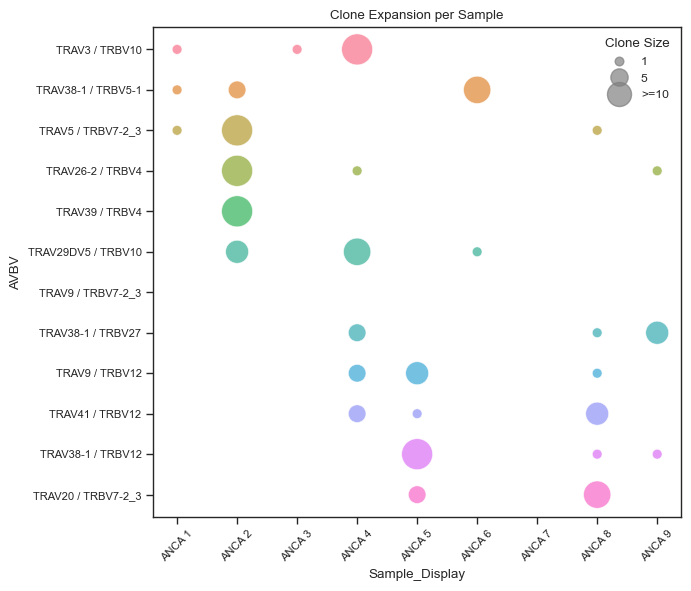

In [35]:
# Plot: AV/BV on y-axis, samples on x-axis, dot size = clone size
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df_long,
    x="Sample_Display",
    y="AVBV",
    hue="color",
    size="CloneSizeCapped",
    sizes=(50, 500),
    alpha=0.7,
)

legend_sizes = [1, 5, 10, 15]  # 15 = ">10"
legend_labels = ["1", "5", ">=10"]
size_scale = lambda x: 10 + (x / 10) * 290  # match your sizes=(10, 300) from sns

# Create the custom legend handles
legend_handles = [
    Line2D(
        [],
        [],
        marker="o",
        linestyle="",
        markersize=(size_scale(s) ** 0.5),
        color="gray",
        alpha=0.7,
        label=l,
    )
    for s, l in zip(legend_sizes, legend_labels)
]
plt.tick_params(axis="both", labelsize=8)
# Add custom legend
plt.legend(handles=legend_handles, title="Clone Size", frameon=False, loc="upper right")
plt.xticks(rotation=45)
plt.title("Clone Expansion per Sample")
plt.tight_layout()
plt.show()

In [36]:
sample_name_map = {sn: f"ANCA {idx}" for idx, sn in enumerate(samples)}

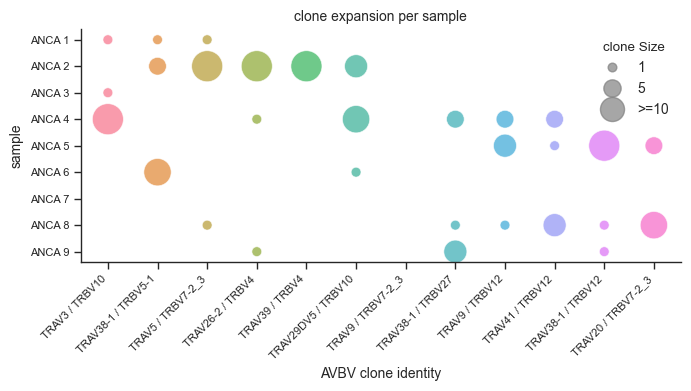

In [47]:
# Plot: AV/BV on y-axis, samples on x-axis, dot size = clone size
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=df_long,
    y="Sample_Display",
    x="AVBV",
    hue="color",
    size="CloneSizeCapped",
    sizes=(50, 500),
    alpha=0.7,
)
sns.despine()
plt.xlabel("AVBV clone identity", fontsize=10)
plt.ylabel("sample", fontsize=10)

legend_sizes = [1, 5, 10, 15]  # 15 = ">10"
legend_labels = ["1", "5", ">=10"]
size_scale = lambda x: 10 + (x / 10) * 290  # match your sizes=(10, 300) from sns

# Create the custom legend handles
legend_handles = [
    Line2D(
        [],
        [],
        marker="o",
        linestyle="",
        markersize=(size_scale(s) ** 0.5),
        color="gray",
        alpha=0.7,
        label=l,
    )
    for s, l in zip(legend_sizes, legend_labels)
]

# Add custom legend
plt.legend(
    handles=legend_handles,
    title="clone Size",
    frameon=False,
    loc="upper right",
    fontsize=10,
)
plt.tick_params(axis="both", labelsize=8)
plt.xticks(rotation=45, ha="right")
plt.title("clone expansion per sample", fontsize=10)
plt.tight_layout()
plt.savefig(
    f"{figure_dir}/Supp02_bubbleRepertoire_mostclones.pdf", dpi=300, bbox_inches="tight"
)